Librerías y Configuración del Dispositivo

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', rc={'figure.figsize': (14, 5), 'grid.alpha': 0.3})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

---
Carga del Dataset

In [7]:
import os
import pandas as pd

ARCHIVO_CSV = 'DEXUSEU.csv'
URL = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUSEU'

# ── Carga de datos ──
if not os.path.exists(ARCHIVO_CSV):
    df_raw = pd.read_csv(URL)
    df_raw.to_csv(ARCHIVO_CSV, index=False)
else:
    df_raw = pd.read_csv(ARCHIVO_CSV)

# ── Estandarización de la fecha ──
# Detectamos cómo se llama la columna y la unificamos a 'DATE'
col_fecha = 'observation_date' if 'observation_date' in df_raw.columns else 'DATE'
df_raw.rename(columns={col_fecha: 'DATE'}, inplace=True)
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])

df_raw.head()

,DATE,DEXUSEU
0,1999-01-04,1.1812
1,1999-01-05,1.1760
2,1999-01-06,1.1636
3,1999-01-07,1.1672
4,1999-01-08,1.1554


Preprocesamiento de la Serie Temporal

In [ ]:
df = df_raw.copy()
df.columns = ['fecha', 'tipo_cambio']

df['tipo_cambio'] = pd.to_numeric(df['tipo_cambio'], errors='coerce')

df = df.dropna().set_index('fecha').sort_index()

df.describe()

,tipo_cambio
count,6814.000000
mean,1.182618
std,0.153084
min,0.827000
25%,1.085200
50%,1.170200
75%,1.297550
max,1.601000


### 3.2 Visualización de la Serie Temporal Completa

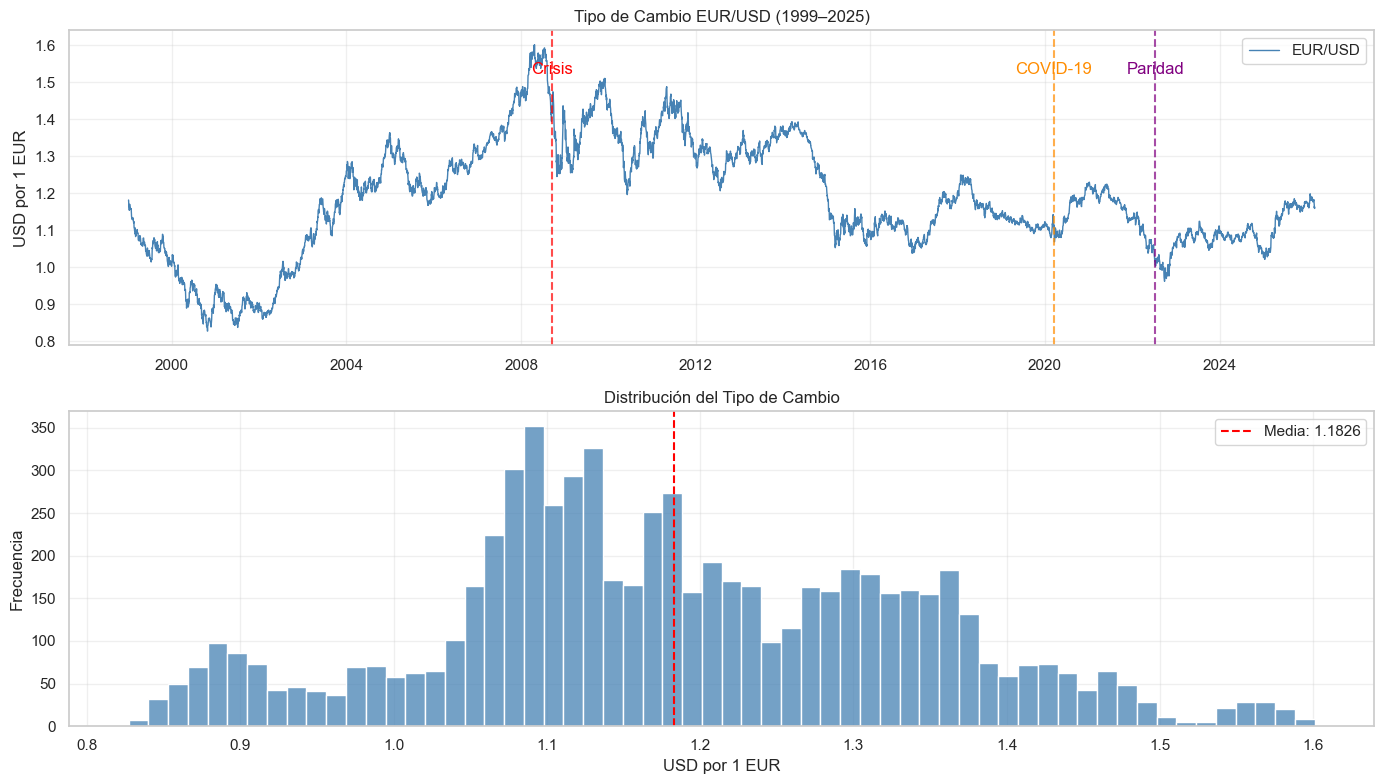

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── 1. Serie temporal EUR/USD ──
axes[0].plot(df.index, df['tipo_cambio'], color='steelblue', lw=1, label='EUR/USD')
axes[0].set(title='Tipo de Cambio EUR/USD (1999–2025)', ylabel='USD por 1 EUR')
axes[0].legend()

# Anotaciones históricas
eventos = {'2008-09-15': ('Crisis', 'red'), 
           '2020-03-15': ('COVID-19', 'darkorange'), 
           '2022-07-13': ('Paridad', 'purple')}

for fecha, (etiqueta, color) in eventos.items():
    fecha_real = df.index.asof(pd.Timestamp(fecha))
    if pd.notna(fecha_real):
        axes[0].axvline(fecha_real, color=color, ls='--', alpha=0.7)
        axes[0].text(fecha_real, df['tipo_cambio'].max() * 0.95, etiqueta, color=color, ha='center')

# ── 2. Distribución (Histograma) ──
sns.histplot(df['tipo_cambio'], bins=60, color='steelblue', ax=axes[1])
media = df['tipo_cambio'].mean()
axes[1].axvline(media, color='red', ls='--', label=f'Media: {media:.4f}')
axes[1].set(title='Distribución del Tipo de Cambio', xlabel='USD por 1 EUR', ylabel='Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_serie_temporal.png', bbox_inches='tight')
plt.show()

### Normalización con MinMaxScaler

In [10]:
# ── Extracción de valores y configuración del escalador ──
valores = df[['tipo_cambio']].values 
scaler = MinMaxScaler(feature_range=(0, 1))

### Creación de Ventanas de Tiempo (Lookback Window)

In [11]:
# ── Configuración de la ventana temporal ──
LOOKBACK = 20

def crear_ventanas(serie, lookback):
    """Convierte una serie temporal en secuencias de entrada (X) y etiquetas (y)."""
    X, y = [], []
    for i in range(len(serie) - lookback):
        X.append(serie[i : i + lookback, 0])
        y.append(serie[i + lookback, 0])
        
    return np.array(X), np.array(y).reshape(-1, 1)


División Temporal en Entrenamiento y Prueba

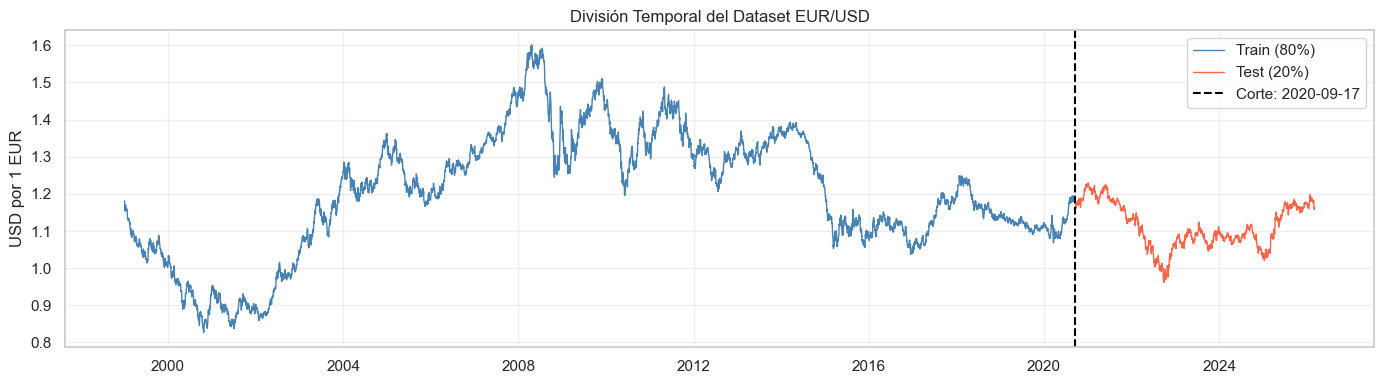

In [12]:
# ── División de datos (80% Train / 20% Test) ──
n_train = int(len(valores) * 0.80)

# Separar series brutas
train_raw, test_raw = valores[:n_train], valores[n_train:]

# Ajustar scaler SOLO en Train y normalizar ambos
train_norm = scaler.fit_transform(train_raw)
test_norm  = scaler.transform(test_raw)

# Crear ventanas temporales
X_train, y_train = crear_ventanas(train_norm, LOOKBACK)
X_test, y_test   = crear_ventanas(test_norm, LOOKBACK)

# ── Visualización del corte ──
plt.figure(figsize=(14, 4))
plt.plot(df.index[:n_train], train_raw, color='steelblue', lw=1, label='Train (80%)')
plt.plot(df.index[n_train:], test_raw, color='tomato', lw=1, label='Test (20%)')
plt.axvline(df.index[n_train], color='black', ls='--', lw=1.5, label=f'Corte: {df.index[n_train].date()}')

plt.title('División Temporal del Dataset EUR/USD')
plt.ylabel('USD por 1 EUR')
plt.legend()
plt.tight_layout()
plt.savefig('02_division_train_test.png', bbox_inches='tight')
plt.show()

###  Conversión a Tensores PyTorch y DataLoaders

In [13]:
from torch.utils.data import TensorDataset

# ── Convertir a tensores ──
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

# ── Crear DataLoaders ──
BATCH_SIZE = 64

dl_train = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
dl_test  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)


 Definición de la Arquitectura MLP

In [14]:
class MLP(nn.Module):
    """Perceptrón Multicapa para regresión de series temporales."""
    def __init__(self, input_size, hidden1=128, hidden2=64, dropout=0.2):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.red(x)

# ── Instanciación del modelo ──
modelo = MLP(input_size=LOOKBACK).to(device)

Entrenamiento del Modelo

In [15]:
# ── Hiperparámetros y Configuración ──
EPOCAS = 150
TASA_APREND = 1e-3

criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=TASA_APREND)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

historial_train, historial_test = [], []

print(f' Iniciando entrenamiento ({EPOCAS} épocas)...')

# ── Bucle de Entrenamiento ──
for epoca in range(1, EPOCAS + 1):
    
    # ── Fase de Entrenamiento ──
    modelo.train()
    perdida_train = 0.0
    
    for X_batch, y_batch in dl_train:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizador.zero_grad()
        perdida = criterio(modelo(X_batch), y_batch)
        perdida.backward()
        optimizador.step()
        
        perdida_train += perdida.item() * len(X_batch)
        
    perdida_train /= len(dl_train.dataset)
    
    # ── Fase de Validación (Test) ──
    modelo.eval()
    perdida_test = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in dl_test:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            perdida = criterio(modelo(X_batch), y_batch)
            perdida_test += perdida.item() * len(X_batch)
            
    perdida_test /= len(dl_test.dataset)
    
    # Actualizar scheduler e historial
    scheduler.step(perdida_test)
    historial_train.append(perdida_train)
    historial_test.append(perdida_test)

    # Imprimir progreso cada 20 épocas
    if epoca == 1 or epoca % 20 == 0:
        lr_actual = optimizador.param_groups[0]['lr']
        print(f"Época {epoca:>3}/{EPOCAS} | Train Loss: {perdida_train:.5f} | Test Loss: {perdida_test:.5f} | LR: {lr_actual:.1e}")

print(f'\n Entrenamiento completado. Loss final - Train: {historial_train[-1]:.5f} | Test: {historial_test[-1]:.5f}')

 Iniciando entrenamiento (150 épocas)...
Época   1/150 | Train Loss: 0.02350 | Test Loss: 0.00028 | LR: 1.0e-03
Época  20/150 | Train Loss: 0.00187 | Test Loss: 0.00020 | LR: 1.0e-03
Época  40/150 | Train Loss: 0.00121 | Test Loss: 0.00008 | LR: 1.0e-03
Época  60/150 | Train Loss: 0.00104 | Test Loss: 0.00007 | LR: 1.0e-03
Época  80/150 | Train Loss: 0.00091 | Test Loss: 0.00010 | LR: 5.0e-04
Época 100/150 | Train Loss: 0.00085 | Test Loss: 0.00006 | LR: 1.3e-04
Época 120/150 | Train Loss: 0.00081 | Test Loss: 0.00006 | LR: 6.3e-05
Época 140/150 | Train Loss: 0.00080 | Test Loss: 0.00006 | LR: 3.1e-05

 Entrenamiento completado. Loss final - Train: 0.00081 | Test: 0.00006


### Curva de Pérdida 

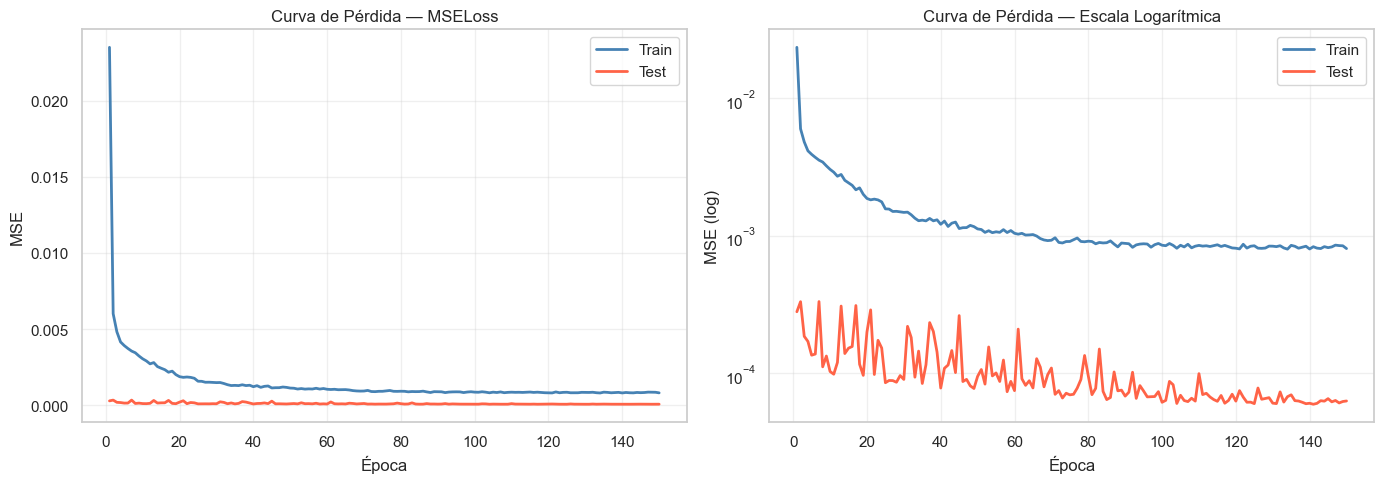

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, EPOCAS + 1)

# ── Dibujar ambas curvas usando un bucle ──
for i, ax in enumerate(axes):
    ax.plot(epocas, historial_train, color='steelblue', lw=2, label='Train')
    ax.plot(epocas, historial_test, color='tomato', lw=2, label='Test')
    
    # Configurar títulos y etiquetas dependiendo del gráfico (0 = Normal, 1 = Log)
    ax.set(xlabel='Época', 
           ylabel='MSE' if i == 0 else 'MSE (log)',
           title='Curva de Pérdida — MSELoss' if i == 0 else 'Curva de Pérdida — Escala Logarítmica')
    
    if i == 1: ax.set_yscale('log') # Cambiar a escala logarítmica para el segundo gráfico
    ax.legend()

plt.tight_layout()
plt.savefig('03_curva_perdida.png', bbox_inches='tight')
plt.show()

Evaluación del Modelo

In [ ]:
# ── Modo evaluación
modelo.eval()

preds_norm  = []   # predicciones normalizadas
reales_norm = []   # valores reales normalizados

with torch.no_grad():
    for X_batch, y_batch in dl_test:
        X_batch = X_batch.to(device)
        y_pred  = modelo(X_batch)
        preds_norm.extend(y_pred.cpu().numpy())
        reales_norm.extend(y_batch.numpy())

# ── Convertir a arrays numpy
preds_norm  = np.array(preds_norm)
reales_norm = np.array(reales_norm)

# ── Desnormalizar
predicciones = scaler.inverse_transform(preds_norm)
reales       = scaler.inverse_transform(reales_norm)

print(f' Predicciones generadas: {len(predicciones):,} valores')
print(f'   Rango predicho  : [{predicciones.min():.4f}, {predicciones.max():.4f}] USD/EUR')
print(f'   Rango real      : [{reales.min():.4f}, {reales.max():.4f}] USD/EUR')

 Predicciones generadas: 1,343 valores
   Rango predicho  : [0.9705, 1.2280] USD/EUR
   Rango real      : [0.9616, 1.2295] USD/EUR


### Predicciones vs Valores Reales (Líneas)

El siguiente gráfico muestra la comparación entre los valores reales del tipo de cambio y las predicciones del modelo sobre el conjunto de prueba.

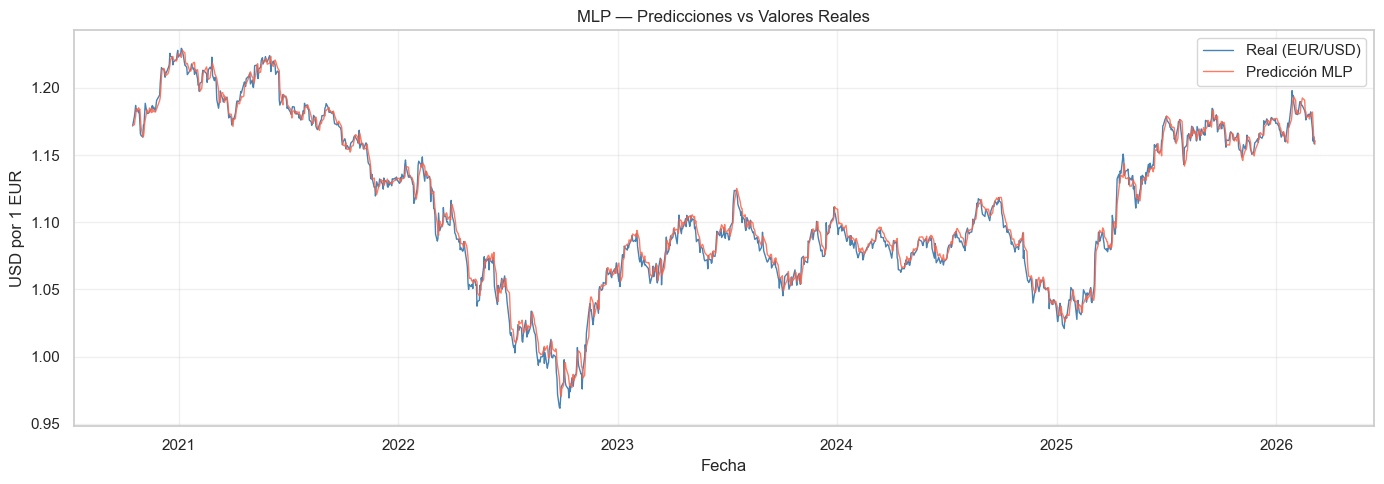

In [22]:
# ── Alinear fechas de prueba y graficar resultados ──
idx_test = n_train + LOOKBACK
fechas_test = df.index[idx_test : idx_test + len(reales)]

plt.figure(figsize=(14, 5))
plt.plot(fechas_test, reales, color='steelblue', lw=1, label='Real (EUR/USD)')
plt.plot(fechas_test, predicciones, color='tomato', lw=1, alpha=0.85, label='Predicción MLP')

# Configuramos títulos y etiquetas en una sola línea usando el eje actual (gca)
plt.gca().set(title='MLP — Predicciones vs Valores Reales', xlabel='Fecha', ylabel='USD por 1 EUR')

plt.legend()
plt.tight_layout()
plt.savefig('04_predicciones_vs_reales.png', bbox_inches='tight')
plt.show()

###  Gráfico de Dispersión: Real vs Predicción

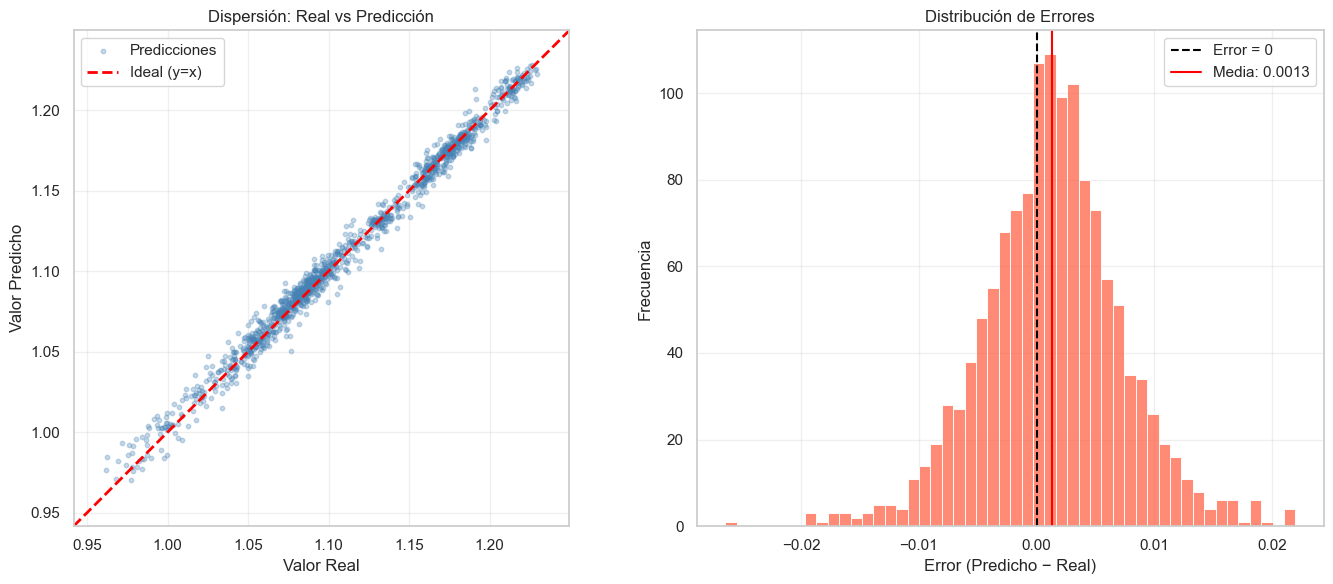

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── 1. Dispersión Real vs Predicción ──
axes[0].scatter(reales, predicciones, alpha=0.3, color='steelblue', s=10, label='Predicciones')

# Línea ideal de predicción perfecta (y = x)
l_min, l_max = min(reales.min(), predicciones.min()) - 0.02, max(reales.max(), predicciones.max()) + 0.02
axes[0].plot([l_min, l_max], [l_min, l_max], color='red', ls='--', lw=2, label='Ideal (y=x)')

axes[0].set(xlim=(l_min, l_max), ylim=(l_min, l_max), aspect='equal',
            title='Dispersión: Real vs Predicción', xlabel='Valor Real', ylabel='Valor Predicho')
axes[0].legend()

# ── 2. Distribución de Errores ──
errores = (predicciones - reales).flatten()
sns.histplot(errores, bins=50, color='tomato', ax=axes[1])

axes[1].axvline(0, color='black', ls='--', lw=1.5, label='Error = 0')
axes[1].axvline(errores.mean(), color='red', ls='-', lw=1.5, label=f'Media: {errores.mean():.4f}')

axes[1].set(title='Distribución de Errores', xlabel='Error (Predicho − Real)', ylabel='Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_dispersion_errores.png', bbox_inches='tight')
plt.show()

Métricas de Error

In [27]:
from sklearn.metrics import mean_absolute_percentage_error

# ── 1. Calcular métricas ──
mae  = mean_absolute_error(reales, predicciones)
rmse = np.sqrt(mean_squared_error(reales, predicciones))
r2   = r2_score(reales, predicciones)
mape = mean_absolute_percentage_error(reales, predicciones) * 100

# ── 2. Lógica de evaluación del R² ──
if r2 > 0.90:   calificacion = "Excelente"
elif r2 > 0.75: calificacion = "Bueno"
else:           calificacion = "Mejorable"

# ── 3. Generar e imprimir el reporte final ──
reporte = f"""
{'=' * 55}
  MÉTRICAS DE EVALUACIÓN DEL MODELO MLP
{'=' * 55}
  MAE  (Error Absoluto Medio)      : {mae:.5f} USD
  RMSE (Raíz del Error Cuadrático) : {rmse:.5f} USD
  MAPE (Error % Absoluto Medio)    : {mape:.2f}%
  R²   (Coef. de Determinación)    : {r2:.5f}
{'=' * 55}

 Interpretación:
 • El modelo predice con un error promedio de {mae:.4f} USD/EUR ({mape:.2f}%).
 • R² = {r2:.4f} → Explica el {r2*100:.1f}% de la varianza. {calificacion}.
"""
print(reporte)


  MÉTRICAS DE EVALUACIÓN DEL MODELO MLP
  MAE  (Error Absoluto Medio)      : 0.00469 USD
  RMSE (Raíz del Error Cuadrático) : 0.00614 USD
  MAPE (Error % Absoluto Medio)    : 0.43%
  R²   (Coef. de Determinación)    : 0.98937

 Interpretación:
 • El modelo predice con un error promedio de 0.0047 USD/EUR (0.43%).
 • R² = 0.9894 → Explica el 98.9% de la varianza. Excelente.



Vista Integrada Final

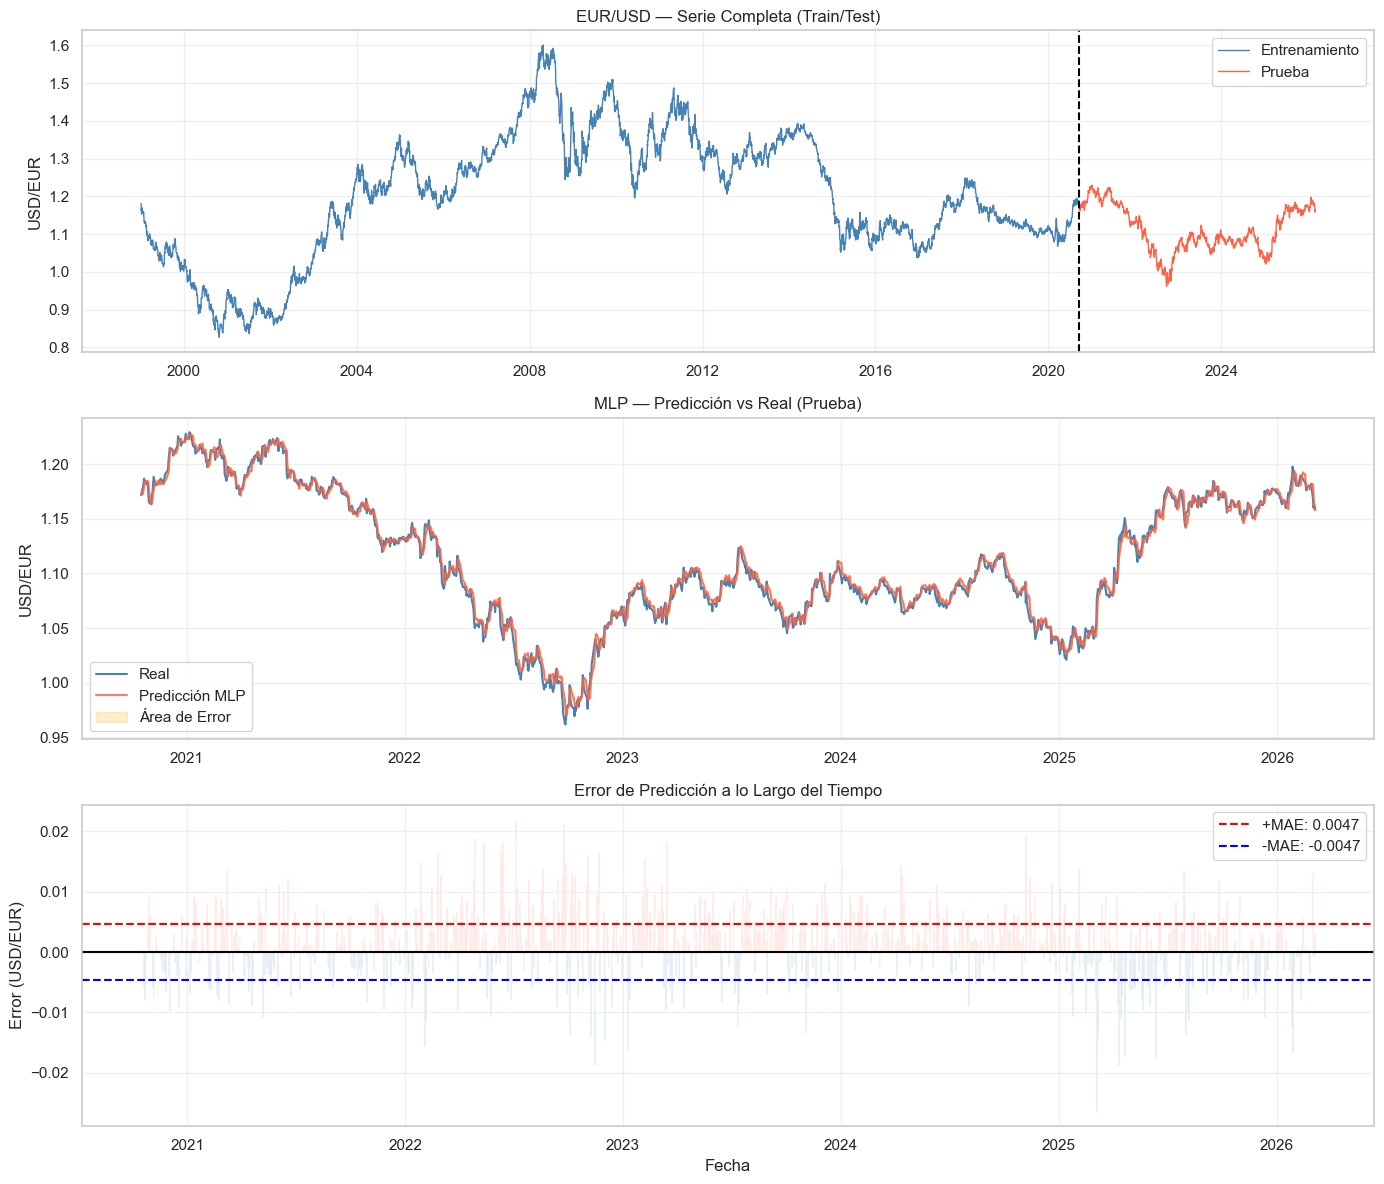

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Preparación de datos 1D (DRY: Don't Repeat Yourself) ──
reales_1d = reales.flatten()
preds_1d  = predicciones.flatten()
err_tiempo = preds_1d - reales_1d

# ── Panel 1: Serie completa con división Train/Test ──
axes[0].plot(df.index[:n_train], df['tipo_cambio'][:n_train], color='steelblue', lw=1, label='Entrenamiento')
axes[0].plot(df.index[n_train:], df['tipo_cambio'][n_train:], color='tomato', lw=1, label='Prueba')
axes[0].axvline(df.index[n_train], color='black', ls='--', lw=1.5)

axes[0].set(title='EUR/USD — Serie Completa (Train/Test)', ylabel='USD/EUR')
axes[0].legend()

# ── Panel 2: Zoom en predicciones vs Real ──
axes[1].plot(fechas_test, reales_1d, color='steelblue', lw=1.5, label='Real')
axes[1].plot(fechas_test, preds_1d, color='tomato', lw=1.5, alpha=0.85, label='Predicción MLP')
axes[1].fill_between(fechas_test, reales_1d, preds_1d, color='orange', alpha=0.2, label='Área de Error')

axes[1].set(title='MLP — Predicción vs Real (Prueba)', ylabel='USD/EUR')
axes[1].legend()

# ── Panel 3: Error a lo largo del tiempo ──
# Truco NumPy: Asignar colores sin usar un bucle 'for'
colores_err = np.where(err_tiempo > 0, 'tomato', 'steelblue')

axes[2].bar(fechas_test, err_tiempo, color=colores_err, alpha=0.6, width=1)
axes[2].axhline(0, color='black', lw=1.5)
axes[2].axhline(mae, color='red', ls='--', lw=1.5, label=f'+MAE: {mae:.4f}')
axes[2].axhline(-mae, color='blue', ls='--', lw=1.5, label=f'-MAE: {-mae:.4f}')

axes[2].set(title='Error de Predicción a lo Largo del Tiempo', xlabel='Fecha', ylabel='Error (USD/EUR)')
axes[2].legend()

plt.tight_layout()
plt.savefig('07_panel_final.png', bbox_inches='tight')
plt.show()


##  Guardado del Modelo Entrenado

In [ ]:
# ── 1. Guardar pesos del modelo entrenado ──
torch.save(modelo.state_dict(), 'modelo_mlp_eurusd.pth')